# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

In [10]:
#%pip install umap-learn


## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("Unit2_ppt4_breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [12]:
p = len(feature_cols)

# Number of distinct feature-to-feature relationships.
n_pairs = comb(p, 2)

# A 10-bin grid grows exponentially as another dimension is added.
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs} (too many scatter plots to inspect manually)")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e} (far too sparse to be practical)")

p = 30 features
Unique pairwise relationships: 435 (too many scatter plots to inspect manually)
Grid cells needed (10 bins/dim): 1.00e+30 (far too sparse to be practical)


**Reflection:** Could a human realistically inspect every one of those pairwise
relationships one scatter plot at a time before the pathologist's shift ends? What does
that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

_Your answer:_ No. Inspecting 435 pairwise plots carefully would be slow and difficult to compare consistently during a shift. A 30-dimensional 10-bin grid is even less feasible because it has $10^{30}$ possible cells, most of which would be empty. PCA, t-SNE, and UMAP therefore provide compact views that make important structure visible without requiring the analyst to inspect every possible relationship separately.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

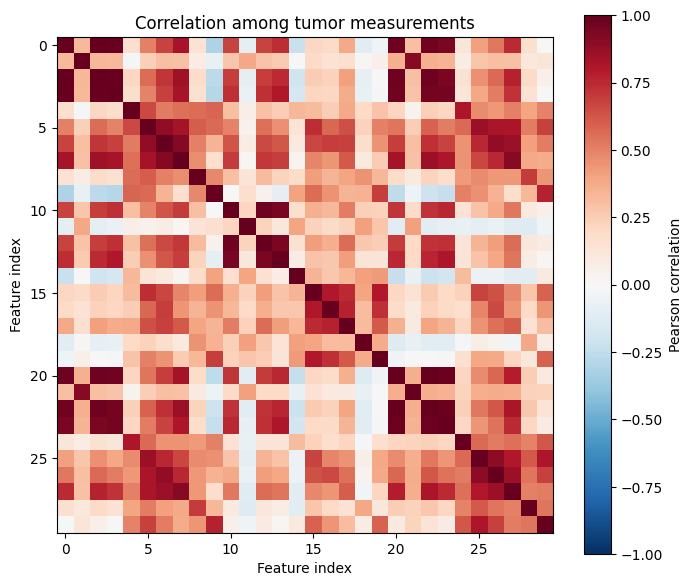

Highly correlated pairs (|r| > 0.9): 21


In [13]:
# Correlation of every pair of numerical measurements.
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Correlation among tumor measurements")
ax.set_xlabel("Feature index")
ax.set_ylabel("Feature index")
fig.colorbar(im, ax=ax, label="Pearson correlation")

plt.show()

# Count only the upper triangle, so each pair is counted once and self-correlations are excluded.
upper_triangle = np.triu(np.ones(corr.shape, dtype=bool), k=1)
high_corr_pairs = ((corr.abs() > 0.9) & upper_triangle).to_numpy().sum()
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)

**Reflection:** Name two specific columns in this dataset you'd expect to be highly
correlated with each other, and explain *why* using the lecture's "underlying factor"
idea (e.g. tumor size).

_Your answer:_ `radius_mean` and `perimeter_mean` should be highly correlated because both measure the underlying tumor-size factor: a larger radius produces a larger perimeter. `area_mean` should also track `radius_mean`, since area grows with the square of radius. These columns are different measurements, but they carry overlapping information about the same physical property.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

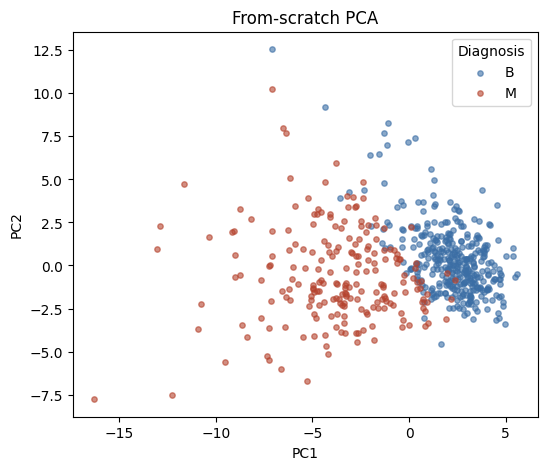

In [14]:
def pca_from_scratch(X, k):
    # Center and standardize each feature using the sample standard deviation.
    X_centered = X - X.mean(axis=0)
    X_scaled = X_centered / X_centered.std(axis=0, ddof=1)

    # Covariance matrix of the standardized features.
    cov = np.cov(X_scaled, rowvar=False)

    # eigh is appropriate for a symmetric covariance matrix; sort descending by variance.
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Project each standardized observation onto the top k principal directions.
    top_eigvecs = eigvecs[:, :k]
    Z = X_scaled @ top_eigvecs

    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("From-scratch PCA")
ax.legend(title="Diagnosis")
plt.show()

**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

_Your answer:_ The two diagnoses show substantial separation in the PCA plot, especially along the first component, but some observations overlap. That overlap does not mean PCA failed: PCA is an unsupervised linear projection that preserves directions of greatest overall variance, not a classifier trained to separate diagnoses. The plot still reveals a strong diagnostic pattern while honestly showing that the measurements do not form two perfectly isolated groups.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

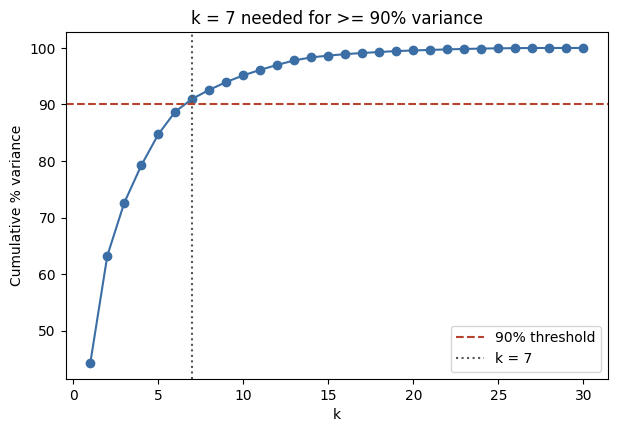

In [15]:
# Fraction of total standardized variance captured by each principal component.
explained_ratio = eigvals / eigvals.sum()

# Running total variance retained as components are added.
cumulative = np.cumsum(explained_ratio)

# np.argmax returns the first index meeting the criterion; add 1 for the component count.
k_90 = np.argmax(cumulative >= 0.90) + 1

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--", label="90% threshold")
ax.axvline(k_90, color="#555555", ls=":", label=f"k = {k_90}")
ax.set_xlabel("k"); ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance")
ax.legend()
plt.show()

**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

_Your answer:_ Here, two components retain about 63.2% of the standardized variance, whereas seven components are needed to reach 90%. A 2D poster therefore discards variation that may contain clinically relevant differences among tumors, including patterns not visible on the two plotted axes. The 2D plot is useful for communication, but it should be presented as a simplified view rather than a complete representation of the data.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

c:\Users\Arjun Mohan Gowda\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


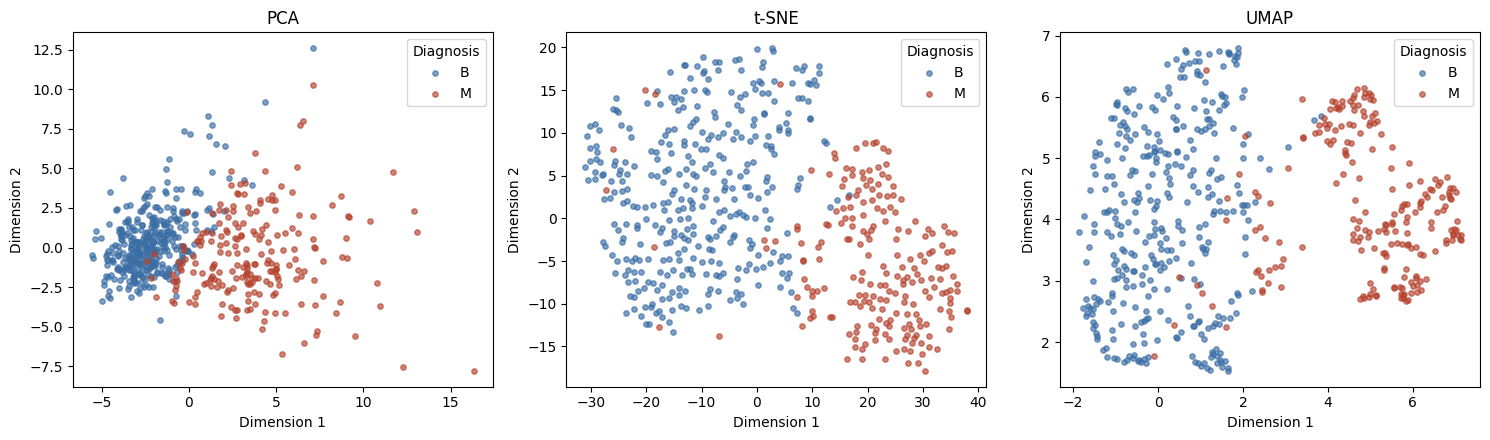

In [16]:
# Put each measurement on the same scale before distance- and variance-based embeddings.
X_scaled = StandardScaler().fit_transform(X_raw)

# All embeddings use the same standardized observations and a fixed seed for reproducibility.
pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X_scaled)
umap_emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=15, alpha=0.65, color=color, label=label)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(name)
    ax.legend(title="Diagnosis")

plt.tight_layout()
plt.show()

**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

_Your answer:_ UMAP gives the cleanest visual separation here, with the two diagnoses forming more distinct regions while retaining some within-group structure. It is not automatically the best method for every dataset. PCA is faster and gives interpretable linear component axes, while t-SNE and UMAP emphasize local neighborhoods and can distort global distances. The choice should follow the purpose of the visualization, not just how cleanly separated the colors appear.

## Task 6 – The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph
justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's
  interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the
  computational-cost comparison, or the "cluster distances shouldn't be over-interpreted"
  caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the
  chosen method's plot.

_Your final recommendation here:_ I would use PCA as the default dashboard view because its linear components provide a stable, fast, and interpretable overview of every patient's measurements. The first two components already reveal a strong benign-versus-malignant pattern, and the component loadings can be connected back to the original measurements. I would include UMAP as an optional exploratory view when the team wants to inspect local neighborhoods or possible subgroups. I would warn the pathologist not to treat a patient's position on a PCA plot as a diagnosis or infer that nearby points alone imply clinical equivalence. The dashboard should support screening and discussion alongside validated diagnostic procedures, not replace them.